## Cell 1 - imports

In [7]:
# Import the libraries used in this notebook section.
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Calculate evaluation metrics to judge model or pipeline performance.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def squeeze_text_column(x):
    return x.squeeze()


## Cell 2 - load cleaned dataset

In [8]:
# Set up project paths so files can be read and outputs can be organised consistently.
cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "notebooks" else cwd
processed_dir = project_root / "data" / "processed"
results_dir = project_root / "results"
part1_results_dir = results_dir / "part1_ml_analysis"
part1_results_dir.mkdir(parents=True, exist_ok=True)

file_path = processed_dir / "ted_cleaned_for_cost_prediction_english.csv"
# Load the dataset needed for the next analysis step.
df = pd.read_csv(file_path, low_memory=False)

print("Dataset path:", file_path)
print("Part 1 results folder:", part1_results_dir)
# Inspect the data to confirm the structure and values look reasonable.
print("Shape:", df.shape)
display(df.head())


Dataset path: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\data\processed\ted_cleaned_for_cost_prediction_english.csv
Part 1 results folder: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\part1_ml_analysis
Shape: (46503, 15)


,TITLE,CPV,ADDITIONAL_CPVS,TYPE_OF_CONTRACT,TOP_TYPE,MAIN_ACTIVITY,CAE_TYPE,ISO_COUNTRY_CODE,TAL_LOCATION_NUTS,LOTS_NUMBER,VALUE_EURO,DISPATCH_YEAR,DISPATCH_MONTH,DISPATCH_QUARTER,LOG_VALUE_EURO
0,Unknown,85000000,Unknown,S,NIC,Health,6,AT,AT,1.0,16257000.00,2022,12,4,16.604034
1,Supply of various vehicles for the Mobile Park...,34144900,Unknown,U,OPE,General public\services,3,ES,ES521,1.0,109000.00,2022,12,4,11.599112
2,Laboratory equipment,38000000,42900000,U,OPE,Health,6,SK,SK,4.0,1942083.33,2022,12,4,14.479272
3,Equipment for sample processing,38000000,42900000,U,OPE,Health,6,SK,SK,4.0,1942083.33,2022,12,4,14.479272
4,Equipment for the needs of the experimental me...,38000000,42900000,U,OPE,Health,6,SK,SK,4.0,1942083.33,2022,12,4,14.479272


## Cell 3 - inspect columns

In [51]:
# Inspect the data to confirm the structure and values look reasonable.
print(df.columns.tolist())

['TITLE', 'CPV', 'ADDITIONAL_CPVS', 'TYPE_OF_CONTRACT', 'TOP_TYPE', 'MAIN_ACTIVITY', 'CAE_TYPE', 'ISO_COUNTRY_CODE', 'TAL_LOCATION_NUTS', 'LOTS_NUMBER', 'VALUE_EURO', 'DISPATCH_YEAR', 'DISPATCH_MONTH', 'DISPATCH_QUARTER', 'LOG_VALUE_EURO']


## Cell 4 - define modelling target

In [52]:
# Define the modelling target and input features.
TARGET_RAW = "VALUE_EURO"
TARGET_LOG = "LOG_VALUE_EURO"

if TARGET_LOG not in df.columns:
    # Convert values into analysis-friendly numeric, date, or text formats.
    df[TARGET_RAW] = pd.to_numeric(df[TARGET_RAW], errors="coerce")
    # Handle missing values so later transformations and models do not fail.
    df = df[df[TARGET_RAW].notna()]
    # Filter the data to keep the records relevant for this step.
    df = df[df[TARGET_RAW] > 0]
    df[TARGET_LOG] = np.log1p(df[TARGET_RAW])

print("Training target:", TARGET_LOG)
print("Predictions will be converted back to VALUE_EURO for reporting.")
# Inspect the data to confirm the structure and values look reasonable.
print(df[[TARGET_RAW, TARGET_LOG]].head())

Training target: LOG_VALUE_EURO
Predictions will be converted back to VALUE_EURO for reporting.
    VALUE_EURO  LOG_VALUE_EURO
0  16257000.00       16.604034
1    109000.00       11.599112
2   1942083.33       14.479272
3   1942083.33       14.479272
4   1942083.33       14.479272


## Cell 5 - TED numeric correlation heat map

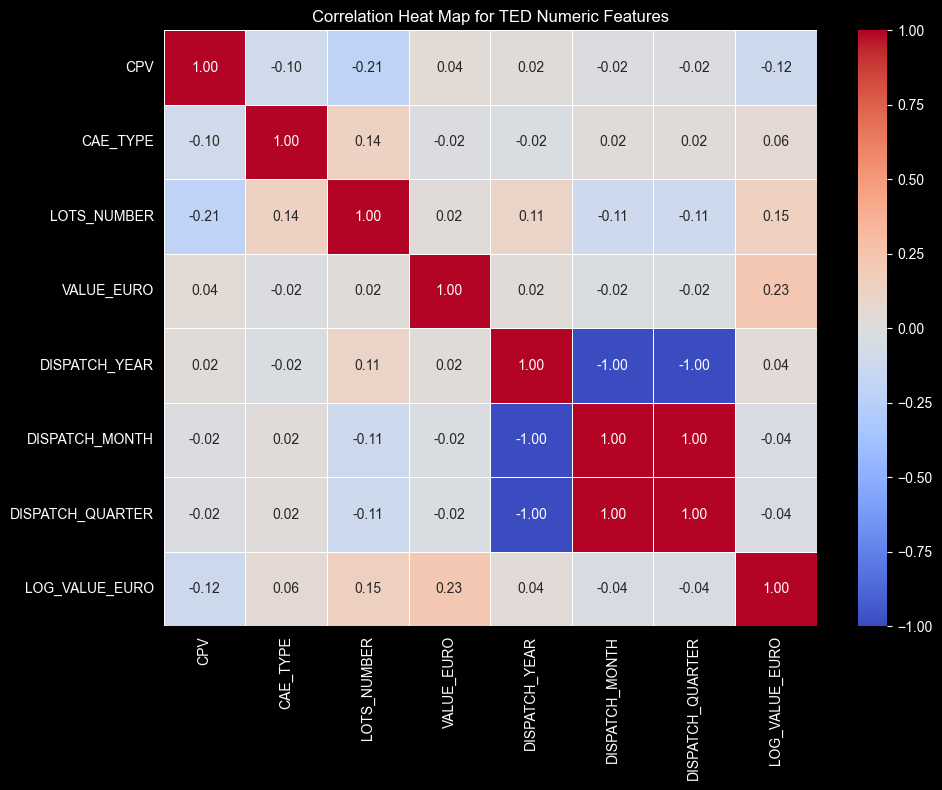

,CPV,CAE_TYPE,LOTS_NUMBER,VALUE_EURO,DISPATCH_YEAR,DISPATCH_MONTH,DISPATCH_QUARTER,LOG_VALUE_EURO
CPV,1.00,-0.10,-0.21,0.04,0.02,-0.02,-0.02,-0.12
CAE_TYPE,-0.10,1.00,0.14,-0.02,-0.02,0.02,0.02,0.06
LOTS_NUMBER,-0.21,0.14,1.00,0.02,0.11,-0.11,-0.11,0.15
VALUE_EURO,0.04,-0.02,0.02,1.00,0.02,-0.02,-0.02,0.23
DISPATCH_YEAR,0.02,-0.02,0.11,0.02,1.00,-1.00,-1.00,0.04
DISPATCH_MONTH,-0.02,0.02,-0.11,-0.02,-1.00,1.00,1.00,-0.04
DISPATCH_QUARTER,-0.02,0.02,-0.11,-0.02,-1.00,1.00,1.00,-0.04
LOG_VALUE_EURO,-0.12,0.06,0.15,0.23,0.04,-0.04,-0.04,1.00


In [9]:
# Choose the columns that will be used as features or summary variables.
numeric_columns = [
    "CPV",
    "CAE_TYPE",
    "LOTS_NUMBER",
    "VALUE_EURO",
    "DISPATCH_YEAR",
    "DISPATCH_MONTH",
    "DISPATCH_QUARTER",
    "LOG_VALUE_EURO",
]

# Convert values into analysis-friendly numeric, date, or text formats.
correlation_df = df[numeric_columns].apply(pd.to_numeric, errors="coerce")
# Calculate correlations between numeric fields to check linear relationships.
correlation_matrix = correlation_df.corr(numeric_only=True)

# Plot the result so the pattern is easier to interpret visually.
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
)
plt.title("Correlation Heat Map for TED Numeric Features")
plt.tight_layout()
plt.show()

# Inspect the data to confirm the structure and values look reasonable.
display(correlation_matrix.round(2))


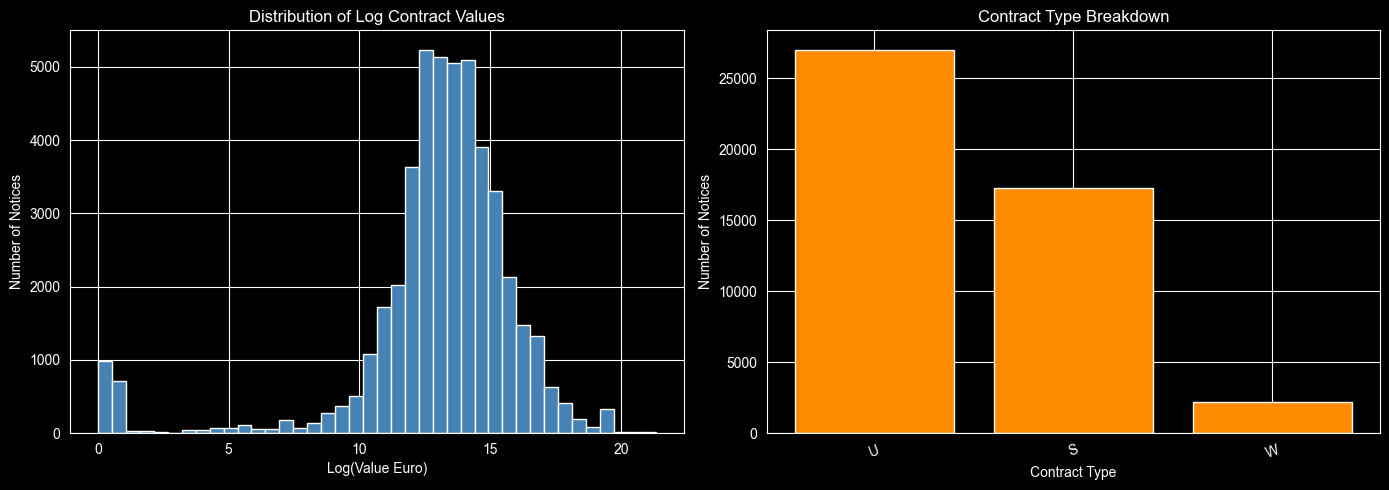

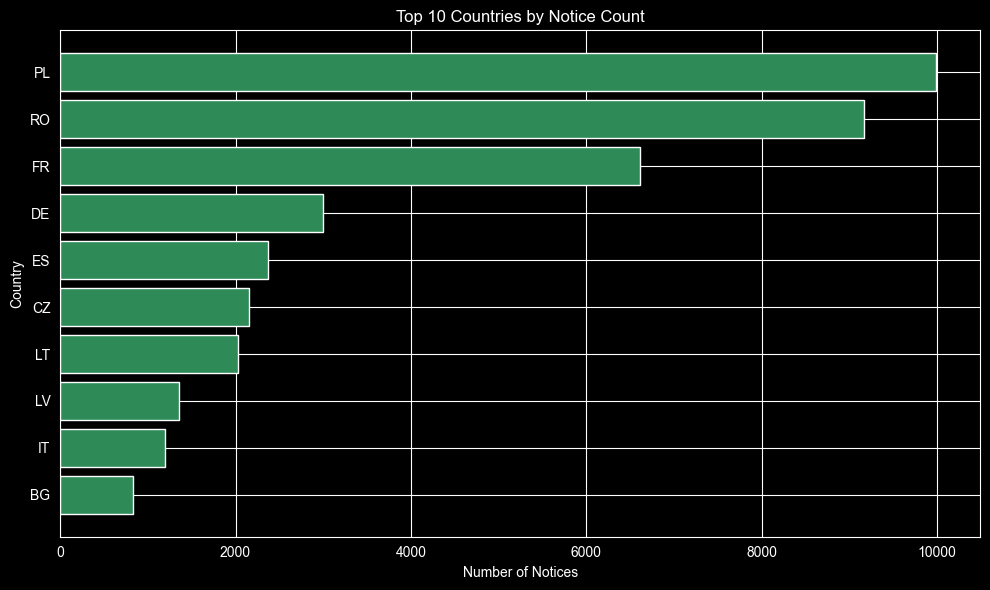

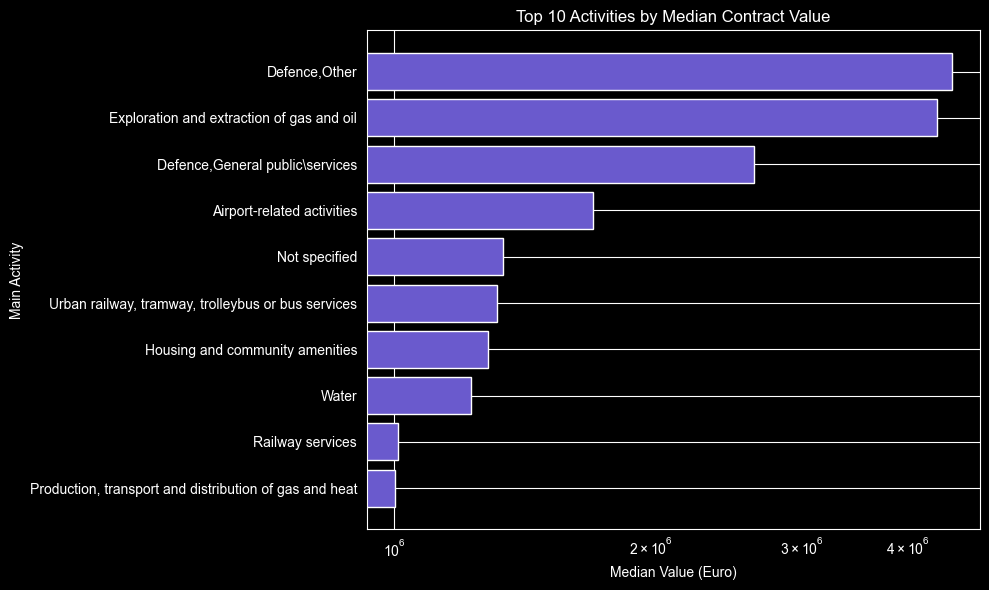

In [53]:
# Plot the result so the pattern is easier to interpret visually.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Handle missing values so later transformations and models do not fail.
axes[0].hist(df[TARGET_LOG].dropna(), bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Log Contract Values")
axes[0].set_xlabel("Log(Value Euro)")
axes[0].set_ylabel("Number of Notices")

# TED uses short contract-type codes: U = Supplies, S = Services, W = Works.
# The chart shows how many records belong to each contract category in the dataset.
contract_type_labels = {"U": "U - Supplies", "S": "S - Services", "W": "W - Works"}
# Filter the data to keep the records relevant for this step.
contract_type_counts = df["TYPE_OF_CONTRACT"].fillna("Unknown").value_counts()
contract_type_counts.index = contract_type_counts.index.map(lambda value: contract_type_labels.get(value, value))
axes[1].bar(contract_type_counts.index, contract_type_counts.values, color="darkorange")
axes[1].set_title("Contract Type Breakdown")
axes[1].set_xlabel("Contract Type")
axes[1].set_ylabel("Number of Notices")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

country_counts = (
    df["ISO_COUNTRY_CODE"]
    .fillna("Unknown")
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(country_counts.index, country_counts.values, color="seagreen")
plt.title("Top 10 Countries by Notice Count")
plt.xlabel("Number of Notices")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

activity_medians = (
    df.dropna(subset=["MAIN_ACTIVITY", TARGET_RAW])
    .groupby("MAIN_ACTIVITY")[TARGET_RAW]
    .median()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(activity_medians.index, activity_medians.values, color="slateblue")
plt.title("Top 10 Activities by Median Contract Value")
plt.xlabel("Median Value (Euro)")
plt.ylabel("Main Activity")
plt.xscale("log")
plt.tight_layout()
plt.show()


## Cell 5 - choose feature columns

In [54]:
# Filter the data to keep the records relevant for this step.
text_features = ["TITLE"]

# Choose the columns that will be used as features or summary variables.
categorical_features = [
    "CPV",
    "ADDITIONAL_CPVS",
    "TYPE_OF_CONTRACT",
    "TOP_TYPE",
    "MAIN_ACTIVITY",
    "CAE_TYPE",
    "ISO_COUNTRY_CODE",
    "TAL_LOCATION_NUTS"
]

numeric_features = [
    "LOTS_NUMBER",
    "DISPATCH_YEAR",
    "DISPATCH_MONTH",
    "DISPATCH_QUARTER"
]

all_features = text_features + categorical_features + numeric_features
existing_features = [col for col in all_features if col in df.columns]

print("Features being used:")
print(existing_features)

Features being used:
['TITLE', 'CPV', 'ADDITIONAL_CPVS', 'TYPE_OF_CONTRACT', 'TOP_TYPE', 'MAIN_ACTIVITY', 'CAE_TYPE', 'ISO_COUNTRY_CODE', 'TAL_LOCATION_NUTS', 'LOTS_NUMBER', 'DISPATCH_YEAR', 'DISPATCH_MONTH', 'DISPATCH_QUARTER']


## Cell 6 - create X and y

In [55]:
# Define the modelling target and input features.
X = df[existing_features].copy()
# Filter the data to keep the records relevant for this step.
y = df[TARGET_LOG].copy()

# Inspect the data to confirm the structure and values look reasonable.
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (46503, 13)
y shape: (46503,)


## Cell 7 - identify actual feature groups present

In [56]:
# Filter the data to keep the records relevant for this step.
text_features = [col for col in text_features if col in X.columns]
# Choose the columns that will be used as features or summary variables.
categorical_features = [col for col in categorical_features if col in X.columns]
numeric_features = [col for col in numeric_features if col in X.columns]

print("Text features:", text_features)
print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

Text features: ['TITLE']
Categorical features: ['CPV', 'ADDITIONAL_CPVS', 'TYPE_OF_CONTRACT', 'TOP_TYPE', 'MAIN_ACTIVITY', 'CAE_TYPE', 'ISO_COUNTRY_CODE', 'TAL_LOCATION_NUTS']
Numeric features: ['LOTS_NUMBER', 'DISPATCH_YEAR', 'DISPATCH_MONTH', 'DISPATCH_QUARTER']


## Cell 8 - train/test split 70/30

In [57]:
# Split the data so model performance can be tested on unseen records.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Inspect the data to confirm the structure and values look reasonable.
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (32552, 13)
Test shape: (13951, 13)


## Cell 9 - preprocessing

In [58]:
# Filter the data to keep the records relevant for this step.
transformers = []

# Choose the columns that will be used as features or summary variables.
if len(text_features) > 0:
    transformers.append(
        (
            "title_tfidf",
            # Build preprocessing steps for numeric, categorical, and text inputs.
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="")),
                ("flatten", FunctionTransformer(squeeze_text_column, validate=False)),
                ("tfidf", TfidfVectorizer(max_features=3000, ngram_range=(1, 2)))
            ]),
            text_features
        )
    )

if len(categorical_features) > 0:
    transformers.append(
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    )

if len(numeric_features) > 0:
    transformers.append(
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        )
    )

preprocessor = ColumnTransformer(transformers=transformers)

## Cell 10 - define models

In [59]:
# Define the model or model set that will be trained and compared.
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    )
}

## Cell 11 - train and evaluate models

In [60]:
# Filter the data to keep the records relevant for this step.
results = []

for model_name, model in models.items():
    print(f"Training {model_name}...")

    # Build preprocessing steps for numeric, categorical, and text inputs.
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train the model or transformer on the prepared data.
    pipeline.fit(X_train, y_train)
    # Generate predictions so they can be compared with actual values.
    y_pred_log = pipeline.predict(X_test)

    # Train and score on the log target
    mae_log = mean_absolute_error(y_test, y_pred_log)
    # Calculate evaluation metrics to judge model or pipeline performance.
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
    r2_log = r2_score(y_test, y_pred_log)

    # Convert predictions back to euro scale for interpretation
    y_test_raw = np.expm1(y_test)
    # Convert values into analysis-friendly numeric, date, or text formats.
    y_pred_raw = np.expm1(y_pred_log)

    mae_raw = mean_absolute_error(y_test_raw, y_pred_raw)
    rmse_raw = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw))
    r2_raw = r2_score(y_test_raw, y_pred_raw)

    results.append({
        "Model": model_name,
        "MAE_Log": mae_log,
        "RMSE_Log": rmse_log,
        "R2_Log": r2_log,
        "MAE_Euro": mae_raw,
        "RMSE_Euro": rmse_raw,
        "R2_Euro": r2_raw
    })

# Summarise the data so patterns can be compared more easily.
results_df = pd.DataFrame(results).sort_values("RMSE_Euro")
# Inspect the data to confirm the structure and values look reasonable.
display(results_df)

Training Linear Regression...
Training Ridge Regression...
Training Random Forest...
Training Gradient Boosting...


,Model,MAE_Log,RMSE_Log,R2_Log,MAE_Euro,RMSE_Euro,R2_Euro
2,Random Forest,0.500236,1.369902,0.820547,1.071878e+06,1.347317e+07,8.186114e-01
1,Ridge Regression,1.010492,1.751356,0.706695,3.539855e+06,2.209989e+07,5.119650e-01
3,Gradient Boosting,1.576314,2.274171,0.505442,5.447824e+06,3.046845e+07,7.237762e-02
0,Linear Regression,1.203369,2.272237,0.506283,1.435609e+09,1.490266e+11,-2.219210e+07


## Cell 12 - identify best model

In [61]:
# Filter the data to keep the records relevant for this step.
best_model_name = results_df.iloc[0]["Model"]
# Calculate evaluation metrics to judge model or pipeline performance.
print("Best model after training on LOG_VALUE_EURO and ranking by RMSE_Euro:", best_model_name)

Best model after training on LOG_VALUE_EURO and ranking by RMSE_Euro: Random Forest


## Cell 13 - retrain best model and keep it

In [62]:
# Filter the data to keep the records relevant for this step.
best_model = models[best_model_name]

# Build preprocessing steps for numeric, categorical, and text inputs.
best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

# Train the model or transformer on the prepared data.
best_pipeline.fit(X_train, y_train)

print("Best model fitted successfully.")

Best model fitted successfully.


## Cell 14 - sample predictions

In [63]:
# Filter the data to keep the records relevant for this step.
sample_preds_log = best_pipeline.predict(X_test.iloc[:100])
# Convert values into analysis-friendly numeric, date, or text formats.
sample_preds_raw = np.expm1(sample_preds_log)

sample_results = pd.DataFrame({
    "Actual_Euro": np.expm1(y_test.iloc[:100].values),
    "Predicted_Euro": sample_preds_raw
})
sample_results["Absolute_Error_Euro"] = (sample_results["Actual_Euro"] - sample_results["Predicted_Euro"]).abs()
sample_results["Percent_Error"] = np.where(
    sample_results["Actual_Euro"] != 0,
    (sample_results["Absolute_Error_Euro"] / sample_results["Actual_Euro"]) * 100,
    np.nan
)

# Inspect the data to confirm the structure and values look reasonable.
display(sample_results)

Saved C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\part1_ml_analysis\part1_sample_prediction_vs_actual.csv


,Actual_Euro,Predicted_Euro,Absolute_Error_Euro,Percent_Error
0,4513420.76,4.513421e+06,8.009374e-08,1.774568e-12
1,182342.00,2.610303e+05,7.868826e+04,4.315421e+01
2,111943.90,1.119439e+05,1.789886e-09,1.598913e-12
3,172632.56,1.527153e+05,1.991730e+04,1.153739e+01
4,340000.00,1.203521e+06,8.635211e+05,2.539768e+02
...,...,...,...,...
95,170349.00,2.432030e+05,7.285400e+04,4.276750e+01
96,740000.00,1.001139e+06,2.611385e+05,3.528899e+01
97,452465.61,5.548789e+05,1.024133e+05,2.263449e+01
98,1727590.67,1.727591e+06,6.053597e-09,3.504069e-13


## Cell 15 - save results table

In [64]:
# Inspect the data to confirm the structure and values look reasonable.
display(results_df)


Saved C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\ted_model_comparison_results_english.csv


### Cell 16 - graph setup and sorted results table

In [65]:
# Import the libraries used in this notebook section.
import matplotlib.pyplot as plt

# Summarise the data so patterns can be compared more easily.
plot_df = results_df.sort_values("RMSE_Euro").reset_index(drop=True)
# Inspect the data to confirm the structure and values look reasonable.
display(plot_df)

,Model,MAE_Log,RMSE_Log,R2_Log,MAE_Euro,RMSE_Euro,R2_Euro
0,Random Forest,0.500236,1.369902,0.820547,1.071878e+06,1.347317e+07,8.186114e-01
1,Ridge Regression,1.010492,1.751356,0.706695,3.539855e+06,2.209989e+07,5.119650e-01
2,Gradient Boosting,1.576314,2.274171,0.505442,5.447824e+06,3.046845e+07,7.237762e-02
3,Linear Regression,1.203369,2.272237,0.506283,1.435609e+09,1.490266e+11,-2.219210e+07


### Cell 17 - RMSE comparison

Saved C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\part1_ml_analysis\part1_model_comparison_rmse_euro.png


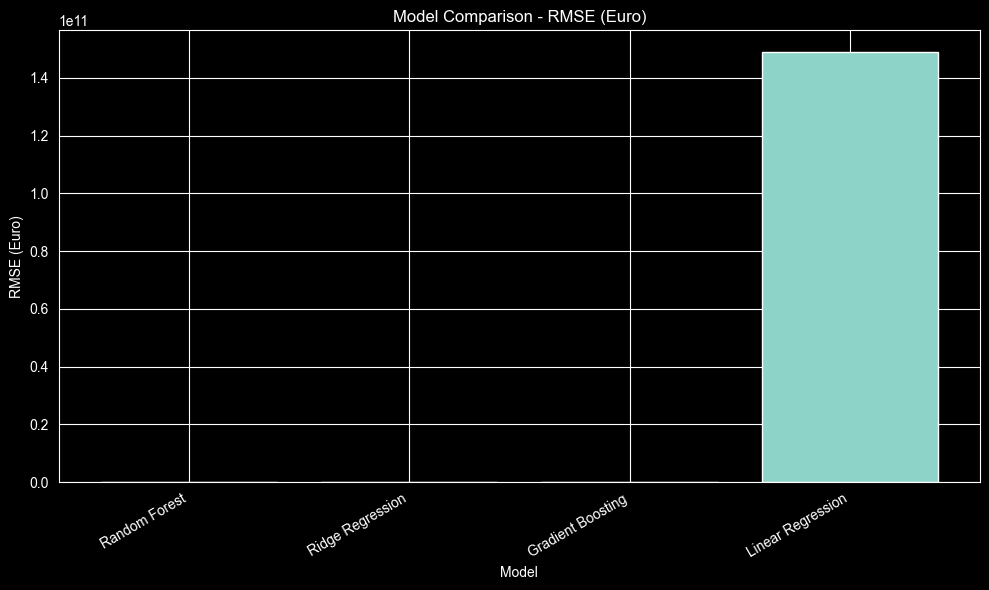

In [66]:
# Plot the result so the pattern is easier to interpret visually.
plt.figure(figsize=(10, 6))
# Calculate evaluation metrics to judge model or pipeline performance.
plt.bar(plot_df["Model"], plot_df["RMSE_Euro"])
plt.title("Model Comparison - RMSE (Euro)")
plt.xlabel("Model")
plt.ylabel("RMSE (Euro)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
# Set up project paths so files can be read and outputs can be organised consistently.
rmse_plot_path = part1_results_dir / "part1_model_comparison_rmse_euro.png"
plt.savefig(rmse_plot_path, dpi=300, bbox_inches="tight")
print(f"Saved {rmse_plot_path}")
plt.show()

### Cell 18 - MAE comparison

Saved C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\part1_ml_analysis\part1_model_comparison_mae_euro.png


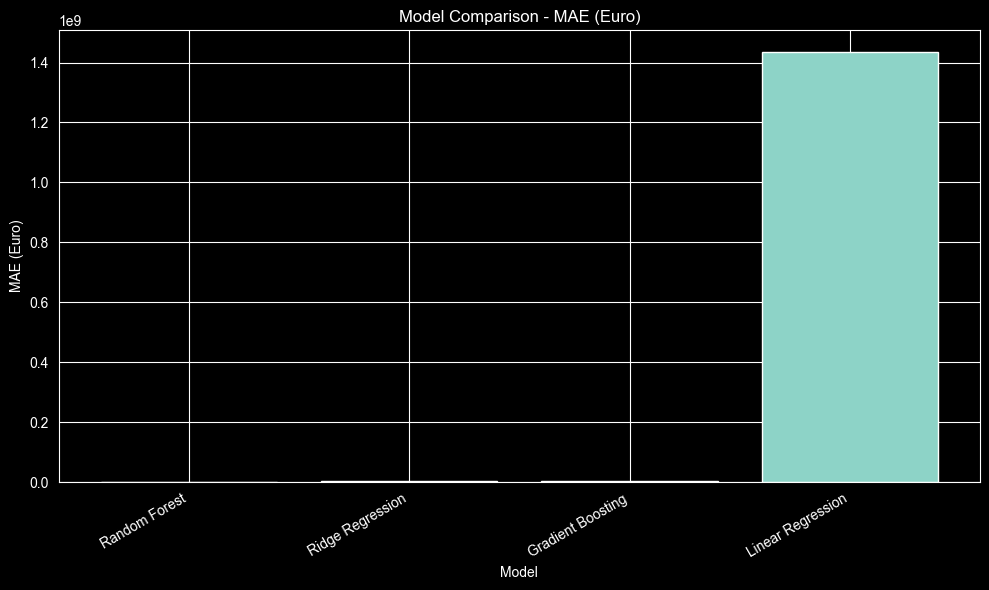

In [67]:
# Plot the result so the pattern is easier to interpret visually.
plt.figure(figsize=(10, 6))
# Calculate evaluation metrics to judge model or pipeline performance.
plt.bar(plot_df["Model"], plot_df["MAE_Euro"])
plt.title("Model Comparison - MAE (Euro)")
plt.xlabel("Model")
plt.ylabel("MAE (Euro)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
# Set up project paths so files can be read and outputs can be organised consistently.
mae_plot_path = part1_results_dir / "part1_model_comparison_mae_euro.png"
plt.savefig(mae_plot_path, dpi=300, bbox_inches="tight")
print(f"Saved {mae_plot_path}")
plt.show()

### Cell 19 - R² comparison

Saved C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\part1_ml_analysis\part1_model_comparison_r2_euro.png


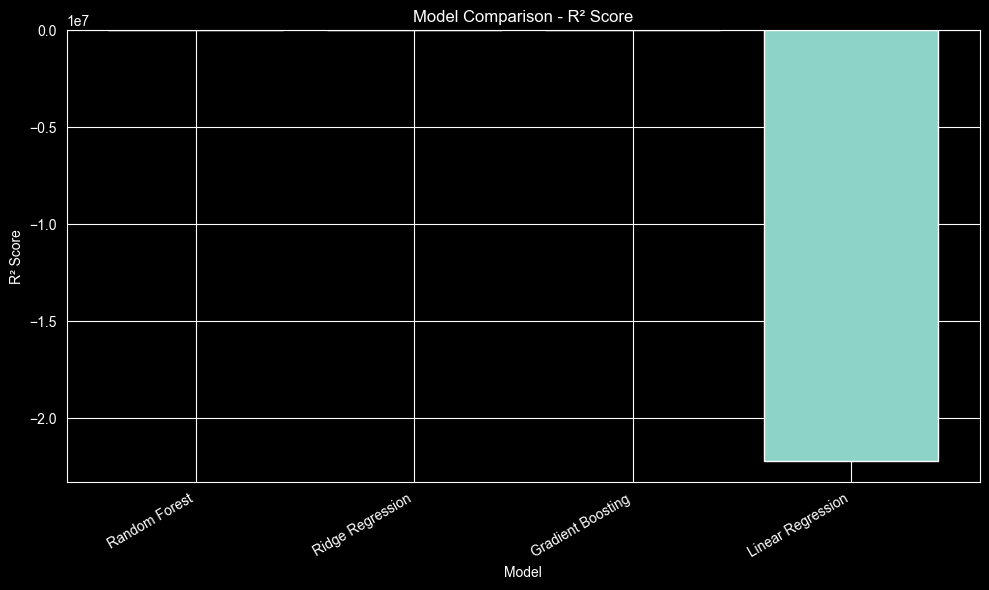

In [68]:
# Plot the result so the pattern is easier to interpret visually.
plt.figure(figsize=(10, 6))
# Calculate evaluation metrics to judge model or pipeline performance.
plt.bar(plot_df["Model"], plot_df["R2_Euro"])
plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
# Set up project paths so files can be read and outputs can be organised consistently.
r2_plot_path = part1_results_dir / "part1_model_comparison_r2_euro.png"
plt.savefig(r2_plot_path, dpi=300, bbox_inches="tight")
print(f"Saved {r2_plot_path}")
plt.show()

### Cell 20 - actual vs predicted for the best model

Saved C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\part1_ml_analysis\part1_actual_vs_predicted_best_model.png


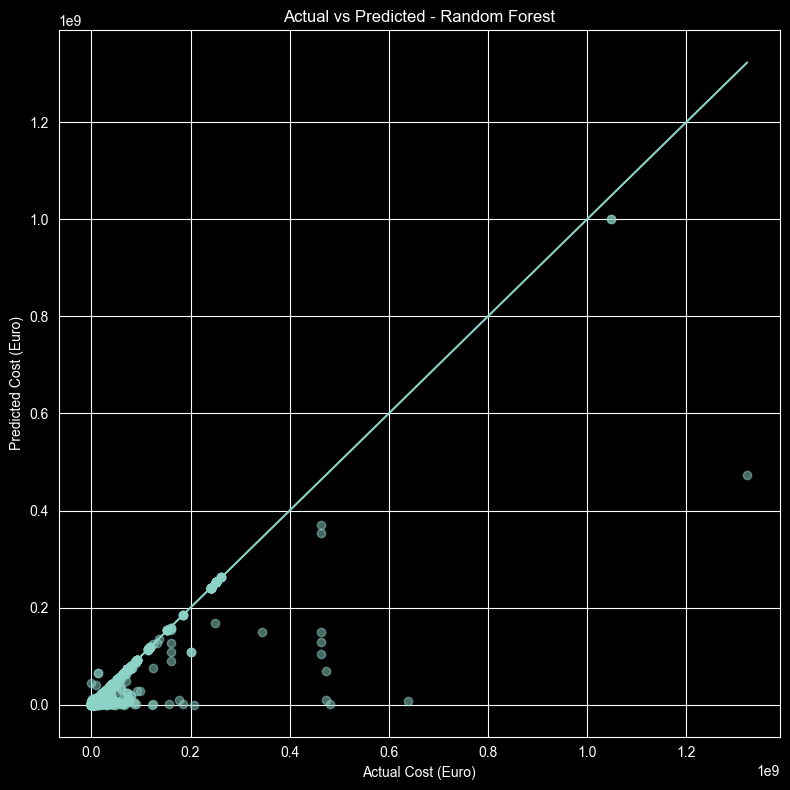

In [69]:
# Generate predictions so they can be compared with actual values.
best_preds_log = best_pipeline.predict(X_test)
# Convert values into analysis-friendly numeric, date, or text formats.
best_preds_raw = np.expm1(best_preds_log)
actual_raw = np.expm1(y_test.values)

# Plot the result so the pattern is easier to interpret visually.
plt.figure(figsize=(8, 8))
plt.scatter(actual_raw, best_preds_raw, alpha=0.5)
plt.plot(
    [actual_raw.min(), actual_raw.max()],
    [actual_raw.min(), actual_raw.max()]
)
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.xlabel("Actual Cost (Euro)")
plt.ylabel("Predicted Cost (Euro)")
plt.tight_layout()
# Set up project paths so files can be read and outputs can be organised consistently.
actual_vs_predicted_path = part1_results_dir / "part1_actual_vs_predicted_best_model.png"
plt.savefig(actual_vs_predicted_path, dpi=300, bbox_inches="tight")
print(f"Saved {actual_vs_predicted_path}")
plt.show()

### Cell 21 - residual plot for the best model

Saved C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\part1_ml_analysis\part1_residual_plot_best_model.png


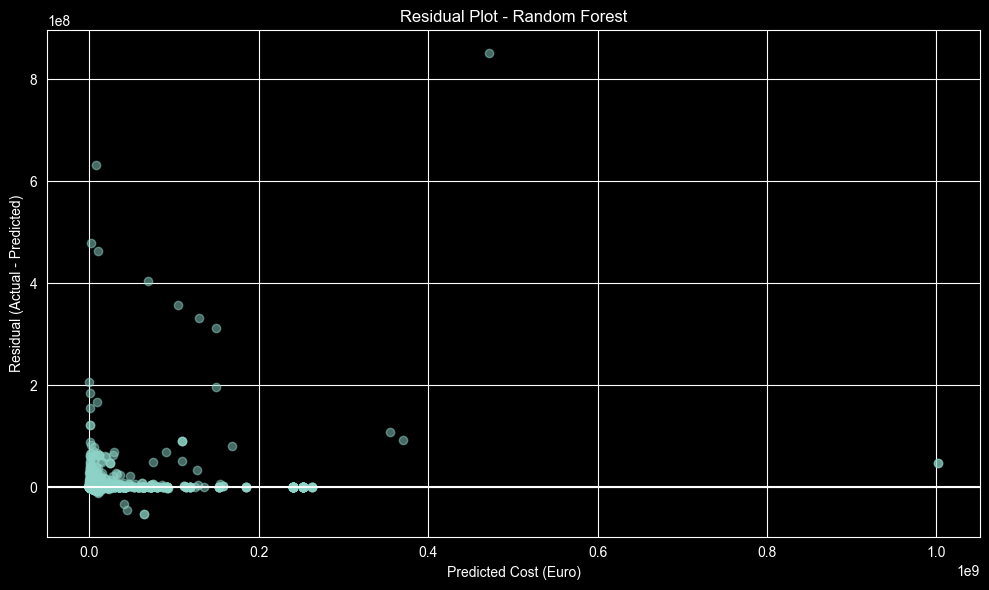

In [70]:
residuals = actual_raw - best_preds_raw

# Plot the result so the pattern is easier to interpret visually.
plt.figure(figsize=(10, 6))
plt.scatter(best_preds_raw, residuals, alpha=0.5)
plt.axhline(y=0)
plt.title(f"Residual Plot - {best_model_name}")
plt.xlabel("Predicted Cost (Euro)")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
# Set up project paths so files can be read and outputs can be organised consistently.
residual_plot_path = part1_results_dir / "part1_residual_plot_best_model.png"
plt.savefig(residual_plot_path, dpi=300, bbox_inches="tight")
print(f"Saved {residual_plot_path}")
plt.show()

## Cell 22 - baseline ranking summary


In [71]:
analysis_df = results_df.copy()

# Filter the data to keep the records relevant for this step.
analysis_df["Rank_RMSE_Euro"] = analysis_df["RMSE_Euro"].rank(method="min")
# Calculate evaluation metrics to judge model or pipeline performance.
analysis_df["Rank_MAE_Euro"] = analysis_df["MAE_Euro"].rank(method="min")
analysis_df["Rank_R2_Euro"] = analysis_df["R2_Euro"].rank(ascending=False, method="min")
analysis_df["Average_Rank"] = (
    analysis_df["Rank_RMSE_Euro"] +
    analysis_df["Rank_MAE_Euro"] +
    analysis_df["Rank_R2_Euro"]
) / 3

# Summarise the data so patterns can be compared more easily.
analysis_df = analysis_df.sort_values(["Average_Rank", "RMSE_Euro"]).reset_index(drop=True)
# Inspect the data to confirm the structure and values look reasonable.
display(analysis_df)

baseline_best_model_name = analysis_df.iloc[0]["Model"]
print("Best baseline model:", baseline_best_model_name)



,Model,MAE_Log,RMSE_Log,R2_Log,MAE_Euro,RMSE_Euro,R2_Euro,Rank_RMSE_Euro,Rank_MAE_Euro,Rank_R2_Euro,Average_Rank
0,Random Forest,0.500236,1.369902,0.820547,1.071878e+06,1.347317e+07,8.186114e-01,1.0,1.0,1.0,1.0
1,Ridge Regression,1.010492,1.751356,0.706695,3.539855e+06,2.209989e+07,5.119650e-01,2.0,2.0,2.0,2.0
2,Gradient Boosting,1.576314,2.274171,0.505442,5.447824e+06,3.046845e+07,7.237762e-02,3.0,3.0,3.0,3.0
3,Linear Regression,1.203369,2.272237,0.506283,1.435609e+09,1.490266e+11,-2.219210e+07,4.0,4.0,4.0,4.0


Best baseline model: Random Forest


## Cell 23 - tuning imports and evaluation helper


In [72]:
# Import the libraries used in this notebook section.
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint


def evaluate_model_predictions(model_name, y_true_log, y_pred_log):
    y_true_log = np.asarray(y_true_log)
    y_pred_log = np.asarray(y_pred_log)

    # Calculate evaluation metrics to judge model or pipeline performance.
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    r2_log = r2_score(y_true_log, y_pred_log)

    # Convert log-scale values back to euros for business-friendly metrics
    y_true_raw = np.expm1(y_true_log)
    # Convert values into analysis-friendly numeric, date, or text formats.
    y_pred_raw = np.expm1(y_pred_log)

    mae_raw = mean_absolute_error(y_true_raw, y_pred_raw)
    rmse_raw = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    r2_raw = r2_score(y_true_raw, y_pred_raw)

    return {
        "Model": model_name,
        "MAE_Log": mae_log,
        "RMSE_Log": rmse_log,
        "R2_Log": r2_log,
        "MAE_Euro": mae_raw,
        "RMSE_Euro": rmse_raw,
        "R2_Euro": r2_raw
    }



## Cell 24 - tune Ridge Regression


In [73]:
# Build preprocessing steps for numeric, categorical, and text inputs.
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    # Define the model or model set that will be trained and compared.
    ("model", Ridge())
])

ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 25.0, 50.0, 100.0]
}

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    # Calculate evaluation metrics to judge model or pipeline performance.
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,
    verbose=1
)

# Train the model or transformer on the prepared data.
ridge_search.fit(X_train, y_train)

print("Best Ridge params:", ridge_search.best_params_)
print("Best Ridge CV RMSE (log scale):", -ridge_search.best_score_)



Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best Ridge params: {'model__alpha': 1.0}
Best Ridge CV RMSE (log scale): 1.8371319145868448


## Cell 25 - tune Random Forest


In [74]:
# Build preprocessing steps for numeric, categorical, and text inputs.
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    # Define the model or model set that will be trained and compared.
    ("model", RandomForestRegressor(random_state=42, n_jobs=1))
])

rf_param_dist = {
    "model__n_estimators": randint(150, 401),
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__min_samples_split": randint(2, 10),
    "model__min_samples_leaf": randint(1, 5),
    "model__max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=15,
    # Calculate evaluation metrics to judge model or pipeline performance.
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=1
)

# Train the model or transformer on the prepared data.
rf_search.fit(X_train, y_train)

print("Best Random Forest params:", rf_search.best_params_)
print("Best Random Forest CV RMSE (log scale):", -rf_search.best_score_)



Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Random Forest params: {'model__max_depth': None, 'model__max_features': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 238}
Best Random Forest CV RMSE (log scale): 1.5378422307769801


## Cell 26 - evaluate tuned models on the test set


In [83]:
# Filter the data to keep the records relevant for this step.
tuned_results = []

best_ridge_pipeline = ridge_search.best_estimator_
best_rf_pipeline = rf_search.best_estimator_

# Generate predictions so they can be compared with actual values.
y_pred_ridge_log = best_ridge_pipeline.predict(X_test)
tuned_results.append(
    evaluate_model_predictions("Ridge Regression (Tuned)", y_test, y_pred_ridge_log)
)

y_pred_rf_log = best_rf_pipeline.predict(X_test)
tuned_results.append(
    evaluate_model_predictions("Random Forest (Tuned)", y_test, y_pred_rf_log)
)

# Summarise the data so patterns can be compared more easily.
tuned_results_df = pd.DataFrame(tuned_results).sort_values("RMSE_Euro").reset_index(drop=True)
# Inspect the data to confirm the structure and values look reasonable.
display(tuned_results_df)



,Model,MAE_Log,RMSE_Log,R2_Log,MAE_Euro,RMSE_Euro,R2_Euro
0,Random Forest (Tuned),0.545182,1.427085,0.805253,1.269089e+06,1.609346e+07,0.741197
1,Ridge Regression (Tuned),1.010492,1.751356,0.706695,3.539855e+06,2.209989e+07,0.511965


## Cell 27 - compare baseline and tuned results


In [84]:
# Combine related tables so each record has the fields needed for analysis.
comparison_df = pd.concat([
    results_df.copy(),
    tuned_results_df.copy()
], ignore_index=True)

# Summarise the data so patterns can be compared more easily.
comparison_df = comparison_df.sort_values("RMSE_Euro").reset_index(drop=True)
# Inspect the data to confirm the structure and values look reasonable.
display(comparison_df)

# Filter the data to keep the records relevant for this step.
final_best_model_name = comparison_df.iloc[0]["Model"]
print("Final best model after tuning:", final_best_model_name)



,Model,MAE_Log,RMSE_Log,R2_Log,MAE_Euro,RMSE_Euro,R2_Euro
0,Random Forest,0.500236,1.369902,0.820547,1.071878e+06,1.347317e+07,8.186114e-01
1,Random Forest (Tuned),0.545182,1.427085,0.805253,1.269089e+06,1.609346e+07,7.411968e-01
2,Ridge Regression (Tuned),1.010492,1.751356,0.706695,3.539855e+06,2.209989e+07,5.119650e-01
3,Ridge Regression,1.010492,1.751356,0.706695,3.539855e+06,2.209989e+07,5.119650e-01
4,Gradient Boosting,1.576314,2.274171,0.505442,5.447824e+06,3.046845e+07,7.237762e-02
5,Linear Regression,1.203369,2.272237,0.506283,1.435609e+09,1.490266e+11,-2.219210e+07


Final best model after tuning: Random Forest


Saved C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\part1_ml_analysis\part1_final_model_comparison_rmse_euro.png


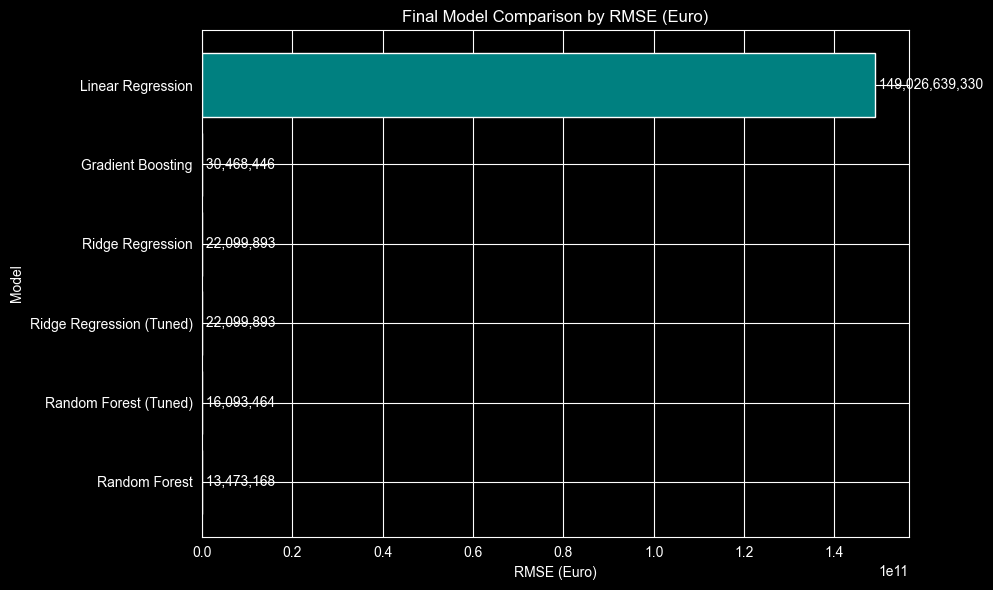

In [85]:
# Extra graph - tuned versus baseline model comparison
final_plot_df = comparison_df.sort_values("RMSE_Euro", ascending=True).reset_index(drop=True)

# Plot the result so the pattern is easier to interpret visually.
plt.figure(figsize=(10, 6))
# Filter the data to keep the records relevant for this step.
bars = plt.barh(final_plot_df["Model"], final_plot_df["RMSE_Euro"], color="teal")
# Calculate evaluation metrics to judge model or pipeline performance.
plt.title("Final Model Comparison by RMSE (Euro)")
plt.xlabel("RMSE (Euro)")
plt.ylabel("Model")

for bar, value in zip(bars, final_plot_df["RMSE_Euro"]):
    plt.text(value, bar.get_y() + bar.get_height() / 2, f" {value:,.0f}", va="center")

plt.tight_layout()
# Set up project paths so files can be read and outputs can be organised consistently.
final_comparison_plot_path = part1_results_dir / "part1_final_model_comparison_rmse_euro.png"
plt.savefig(final_comparison_plot_path, dpi=300, bbox_inches="tight")
print(f"Saved {final_comparison_plot_path}")
plt.show()


## Cell 28 - keep the final best pipeline


In [86]:
candidate_pipelines = {
    # Build preprocessing steps for numeric, categorical, and text inputs.
    "Linear Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", models["Linear Regression"])
    ]),
    "Ridge Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", models["Ridge Regression"])
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", models["Random Forest"])
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", models["Gradient Boosting"])
    ]),
    "Ridge Regression (Tuned)": best_ridge_pipeline,
    "Random Forest (Tuned)": best_rf_pipeline
}

# Filter the data to keep the records relevant for this step.
final_best_pipeline = candidate_pipelines[final_best_model_name]
# Train the model or transformer on the prepared data.
final_best_pipeline.fit(X_train, y_train)

print("Final best pipeline fitted successfully.")



Final best pipeline fitted successfully.


## Cell 29 - final best model predictions


In [87]:
# Generate predictions so they can be compared with actual values.
final_preds_log = final_best_pipeline.predict(X_test)
# Convert values into analysis-friendly numeric, date, or text formats.
final_preds_raw = np.expm1(final_preds_log)
actual_raw_final = np.expm1(y_test.to_numpy())

final_predictions_df = pd.DataFrame({
    "Actual_Euro": actual_raw_final[:10],
    "Predicted_Euro": final_preds_raw[:10]
})
# Filter the data to keep the records relevant for this step.
final_predictions_df["Absolute_Error_Euro"] = (final_predictions_df["Actual_Euro"] - final_predictions_df["Predicted_Euro"]).abs()
final_predictions_df["Percent_Error"] = np.where(
    final_predictions_df["Actual_Euro"] != 0,
    (final_predictions_df["Absolute_Error_Euro"] / final_predictions_df["Actual_Euro"]) * 100,
    np.nan
)

# Set up project paths so files can be read and outputs can be organised consistently.
final_predictions_path = part1_results_dir / "part1_final_prediction_vs_actual.csv"
# Save the processed output so later notebooks or report sections can reuse it.
final_predictions_df.to_csv(final_predictions_path, index=False)
print(f"Saved {final_predictions_path}")

# Inspect the data to confirm the structure and values look reasonable.
display(final_predictions_df)



Saved C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\part1_ml_analysis\part1_final_prediction_vs_actual.csv


,Actual_Euro,Predicted_Euro,Absolute_Error_Euro,Percent_Error
0,4513420.76,4.513421e+06,8.009374e-08,1.774568e-12
1,182342.00,2.610303e+05,7.868826e+04,4.315421e+01
2,111943.90,1.119439e+05,1.789886e-09,1.598913e-12
3,172632.56,1.527153e+05,1.991730e+04,1.153739e+01
4,340000.00,1.203521e+06,8.635211e+05,2.539768e+02
5,1489350.45,1.489350e+06,4.237518e-08,2.845212e-12
6,28553.79,3.306715e+04,4.513361e+03,1.580652e+01
7,1250000.00,1.250000e+06,2.002344e-08,1.601875e-12
8,911514.34,4.883832e+05,4.231311e+05,4.642068e+01
9,0.01,1.000000e-02,1.040834e-17,1.040834e-13


## Cell 30 - save final comparison tables


In [88]:
# Calculate evaluation metrics to judge model or pipeline performance.
part1_results_df = comparison_df.copy()
# Filter the data to keep the records relevant for this step.
part1_results_df["Rank_RMSE_Euro"] = part1_results_df["RMSE_Euro"].rank(method="min")
part1_results_df["Rank_MAE_Euro"] = part1_results_df["MAE_Euro"].rank(method="min")
part1_results_df["Rank_R2_Euro"] = part1_results_df["R2_Euro"].rank(ascending=False, method="min")
part1_results_df["Average_Rank"] = (
    part1_results_df["Rank_RMSE_Euro"]
    + part1_results_df["Rank_MAE_Euro"]
    + part1_results_df["Rank_R2_Euro"]
) / 3

# Summarise the data so patterns can be compared more easily.
part1_results_df = part1_results_df.sort_values(
    ["Average_Rank", "RMSE_Euro"]
).reset_index(drop=True)

# Set up project paths so files can be read and outputs can be organised consistently.
part1_final_comparison_path = part1_results_dir / "part1_final_model_comparison.csv"
# Save the processed output so later notebooks or report sections can reuse it.
part1_results_df.to_csv(part1_final_comparison_path, index=False)

# Inspect the data to confirm the structure and values look reasonable.
display(part1_results_df)
print(f"Saved {part1_final_comparison_path}")


,Model,MAE_Log,RMSE_Log,R2_Log,MAE_Euro,RMSE_Euro,R2_Euro,Rank_RMSE_Euro,Rank_MAE_Euro,Rank_R2_Euro,Average_Rank
0,Random Forest,0.500236,1.369902,0.820547,1.071878e+06,1.347317e+07,8.186114e-01,1.0,1.0,1.0,1.0
1,Random Forest (Tuned),0.545182,1.427085,0.805253,1.269089e+06,1.609346e+07,7.411968e-01,2.0,2.0,2.0,2.0
2,Ridge Regression (Tuned),1.010492,1.751356,0.706695,3.539855e+06,2.209989e+07,5.119650e-01,3.0,3.0,3.0,3.0
3,Ridge Regression,1.010492,1.751356,0.706695,3.539855e+06,2.209989e+07,5.119650e-01,3.0,3.0,3.0,3.0
4,Gradient Boosting,1.576314,2.274171,0.505442,5.447824e+06,3.046845e+07,7.237762e-02,5.0,5.0,5.0,5.0
5,Linear Regression,1.203369,2.272237,0.506283,1.435609e+09,1.490266e+11,-2.219210e+07,6.0,6.0,6.0,6.0


Saved C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\part1_ml_analysis\part1_final_model_comparison.csv
